# 什么是无监督学习

**回忆无监督学习的特点？**

- 监督学习是一种目的明确的训练方式，你知道得到的是什么；而无监督学习则是没有明确目的的训练方式，你无法提前知道结果是什么。
- 监督学习需要给数据打标签；而无监督学习不需要给数据打标签。
- 监督学习由于目标明确，所以可以衡量效果；而无监督学习几乎无法量化效果如何。

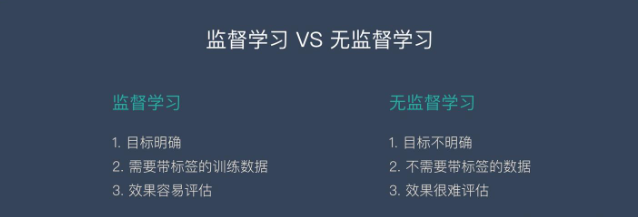

**无监督学习是一种机器学习的训练方式，它本质上是一个统计手段，在没有标签的数据里可以发现潜在的一些结构的一种训练方式。**

# K-means聚类
## 基本思想

图中的数据可以分成三个分开的点集(称为簇)，一个能够分出这些点集的算法，就被称为聚类算法。
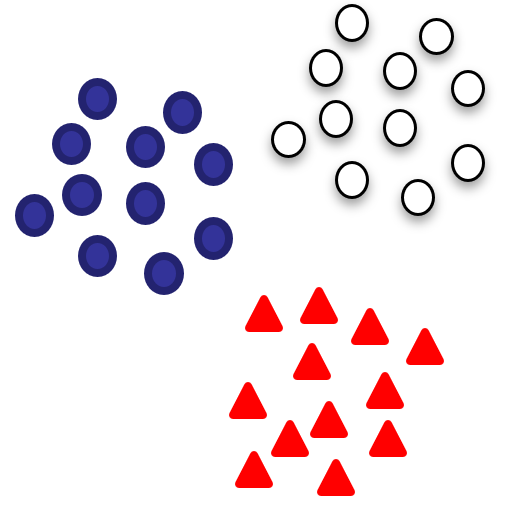

## K-means算法概述

    K-means算法是一种无监督学习方法，是最普及的聚类算法，算法使用一个没有标签的数据集，然后将数据聚类成不同的组。                  
    K-means算法具有一个迭代过程，在这个过程中，数据集被分组成若干个预定义的不重叠的聚类或子组，使簇的内部点尽可能相似，同时试图保持簇在不同的空间，它将数据点分配给簇，以便簇的质心和数据点之间的平方距离之和最小，在这个位置，簇的质心是簇中数据点的算术平均值。
    
## K-means算法流程
1. 选择K个点作为初始质心。
2. 将每个点指派到最近的质心，形成K个簇。
3. 对于上一步聚类的结果，进行平均计算，得出该簇的新的聚类中心。
4. 重复上述两步/直到迭代结束：质心不发生变化。
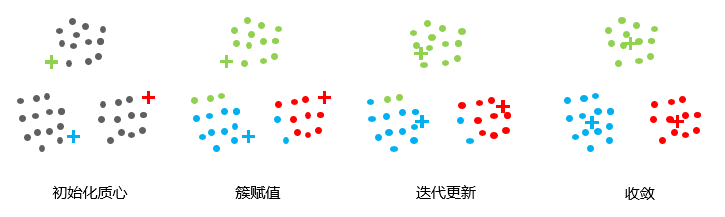

## K值的选择

现在我们需要找到簇的数量。通常通过“肘部法则”进行计算。我们可能会得到一条类似于人的肘部的曲线。下图中，代价函数的值会迅速下降，在𝐾 = 3的时候达到一个肘点。在此之后，代价函数的值会就下降得非常慢，所以，我们选择𝐾 = 3。这个方法叫“肘部法则”。

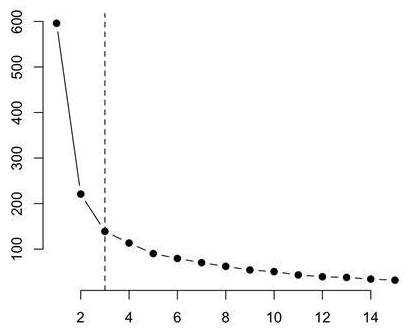

- Y轴：代价函数值
- X轴：聚类数量K

## K-means API
- sklearn.cluster.KMeans(n_clusters=8,init=‘k-means++’)
    - 参数：
    - n_clusters:开始的聚类中心数量
    - init:初始化方法，默认为'k-means ++’
    - max_iter:最大迭代次数
    
    - 属性：
    - labels_:默认标记的类型，可以和真实值比较（不是值比较）
    - cluster_centers_	:最终的聚类中心坐标
    - inertia_:总惯性值（簇内平方和）
    - n_iter_:实际迭代次数

**问题：如何去评估聚类的效果呢？**

## Kmeans性能评估指标

### 轮廓系数
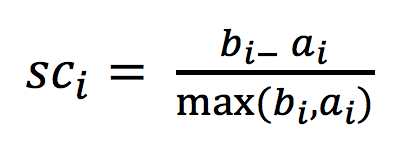

注：对于每个点i 为已聚类数据中的样本 ，$b_i$ 为i 到其它族群的所有样本的距离最小值，$a_i$ 为i 到本身簇的距离平均值。最终计算出所有的样本点的轮廓系数平均值

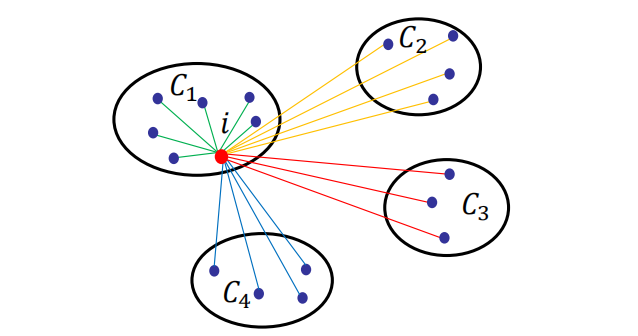

    假设数据集被拆分为4个簇，样本𝑖对应的𝑎(𝑖)值就是所有𝐶1 中其他样本点与样本𝑖的距离平均值;
    样本对应的𝑏(𝑖)值分两步计算，首先计算该点分别到𝐶2、 𝐶3和𝐶4中样本点的平均距离，然后将三个平均值中的最小值作为𝑏(𝑖)的度量。

### 轮廓系数值分析
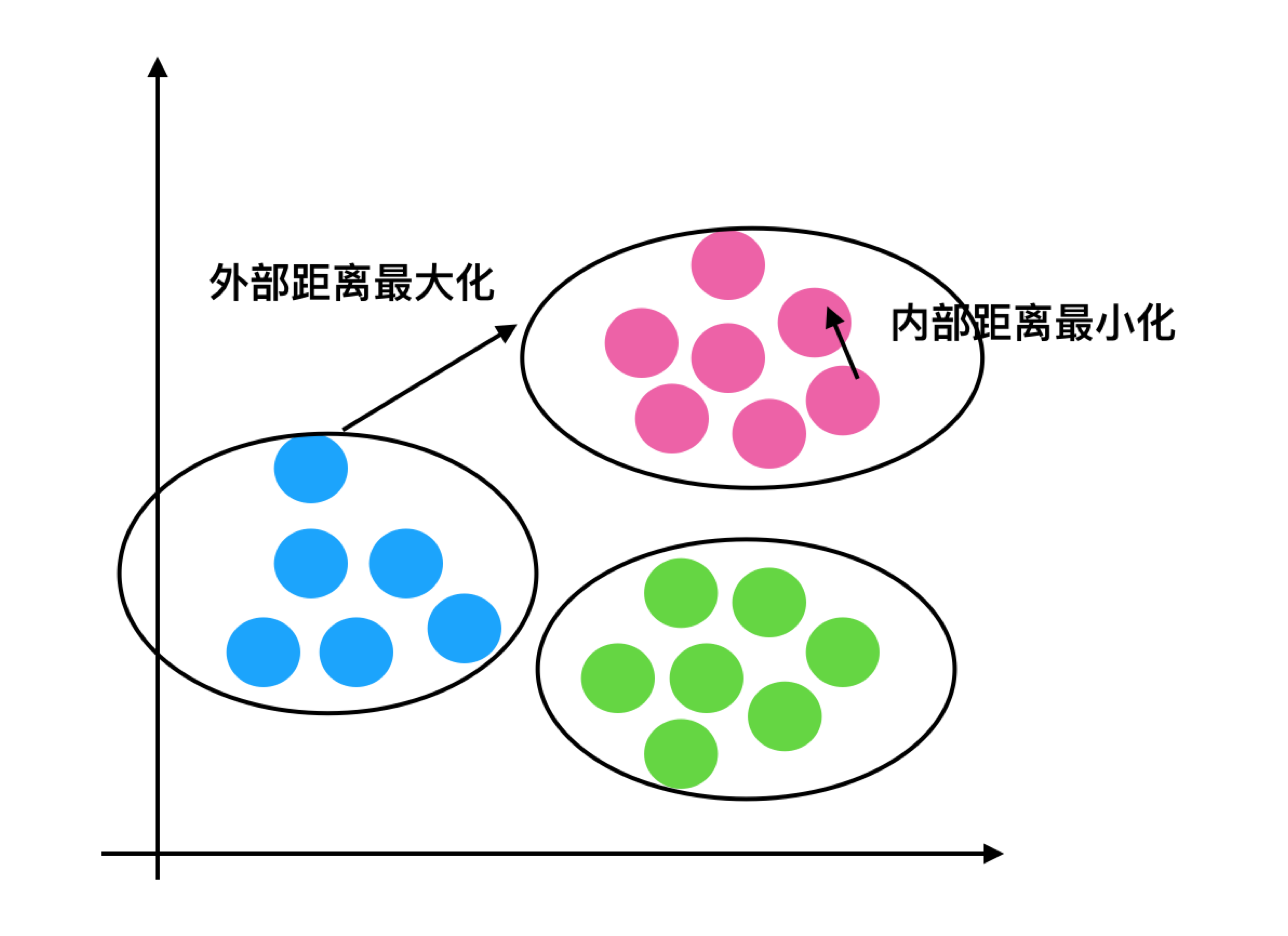

轮廓系数𝑠c(𝑖)值越接近1表示样本𝑖聚类越合理，越接近-1，表示样本𝑖应该分类到另外的簇中，近似为0，表示样本𝑖应该在边界上;所有样本的𝑠c(𝑖)的均值被成为聚类结果的轮廓系数。

### 轮廓系数API
- sklearn.metrics.silhouette_score(X, labels)
    - 计算所有样本的平均轮廓系数
    - X：特征值
    - labels：被聚类标记的目标值
    - metric：距离计算方式
    
## K-means 聚类实战



### 一、前期准备：库导入与环境配置

In [29]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')  # 屏蔽无关警告
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, silhouette_score
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False

- pandas和numpy是数据处理的基础库，负责数据加载、格式转换；
- sklearn.cluster.KMeans是核心 ——sklearn 库中实现 K-means 聚类的 API；
- silhouette_score（轮廓系数）是评估聚类效果的指标，前者需要真实标签，后者是无监督评估；
- matplotlib.pyplot用于可视化，后面两行是解决 matplotlib 显示中文和负号乱码的问题，这是实战中很常见的小技巧。

### 二、数据加载与预处理：聚类的基础

- np.random.seed(0)：固定随机种子，保证后续所有涉及随机的操作（比如 KMeans 初始化）结果可复现，这是实验可重复的关键；
- data = pd.read_csv('data.csv')：加载本地的 CSV 数据文件，这是实战中最常见的数据源方式；
- data.head()和data.info()：打印数据前 5 行和基本信息（列名、数据类型、缺失值），是数据探索的第一步 —— 我们需要先知道数据长什么样，有没有缺失值、异常值；
- 定义特征和标签：
    - X = data.drop(['labels'], axis=1)：去掉标签列，只保留用于聚类的特征（比如这里的 V1、V2），聚类是无监督学习，训练时其实不需要标签，但我们这里有真实标签，后续可以用来评估效果；
    - y = data['labels']：提取真实标签，简化了原有的loc用法，效果完全一致，代码更简洁。

In [30]:

# ===================== 1. 数据加载与预处理 =====================
np.random.seed(0)
# -------- 真实数据加载 --------
data = pd.read_csv('data.csv')

print("数据预览：")
print(data.head())
print("\n数据基本信息：")
print(data.info())

# 定义特征X和真实标签y
X = data.drop(['labels'], axis=1)
y = data['labels']  # 简化loc用法，等价于data.loc[:,'labels']

数据预览：
          V1         V2  labels
0   2.072345  -3.241693       0
1  17.936710  15.784810       0
2   1.083576   7.319176       0
3  11.120670  14.406780       0
4  23.711550   2.557729       0

数据基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      3000 non-null   float64
 1   V2      3000 non-null   float64
 2   labels  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB
None


### 三、肘部法则：选对聚类数 k
K-means 的核心是确定聚类数 k，这里用了经典的 “肘部法则”：

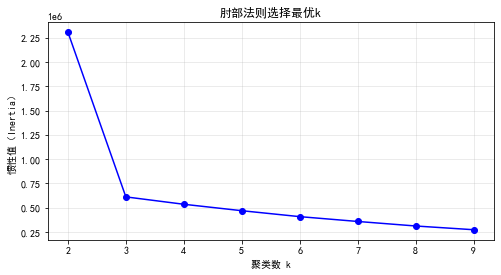

In [23]:
# ===================== 2. 肘部法则选最优k =====================
loss = []
k_range = range(2, 10)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=0)  # 固定random_state保证可复现
    model.fit(X)
    loss.append(model.inertia_)

# 可视化肘部图
plt.figure(figsize=(8, 4))
plt.plot(k_range, loss, marker='o', color='b', linewidth=1.5)
plt.xlabel('聚类数 k')
plt.ylabel('惯性值（Inertia）')
plt.title('肘部法则选择最优k')
plt.grid(alpha=0.3)
plt.show()

# 查看真实标签分布
y_count = pd.value_counts(y)

- 核心逻辑：遍历 k 从 2 到 9（聚类数至少为 2，否则无意义），每个 k 训练一个 KMeans 模型，记录模型的inertia_（惯性值）；
    - 惯性值的含义是 “所有样本到其所属聚类中心的平方和”，值越小说明簇内样本越紧凑，聚类效果越好；
    - 但 k 越大，惯性值一定会持续下降（k 等于样本数时，惯性值为 0），所以我们要找 “惯性值下降速率骤减” 的点 —— 也就是 “肘部”，这个点的 k 就是最优值；
- 可视化肘部图：
    - plt.figure(figsize=(8, 4))设置图表大小，plot绘制 k 和惯性值的折线图，加marker='o'显示每个 k 对应的点，更直观；
    - grid(alpha=0.3)添加浅灰色网格，提升图表可读性；
- pd.value_counts(y)：统计真实标签的分布，比如有多少个 0 类、1 类、2 类样本，后续可以和聚类结果对比。

### 四、原始数据可视化：直观看数据分布

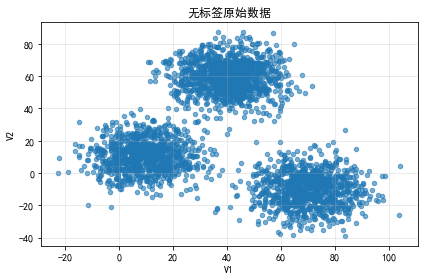

In [24]:
# ===================== 3. 原始数据与标注数据可视化 =====================
# 子图布局：1行2列，对比无标签/有标签数据
fig, ax1 = plt.subplots()

# 无标签数据
ax1.scatter(X['V1'], X['V2'], alpha=0.6, s=20)
ax1.set_title("无标签原始数据")
ax1.set_xlabel('V1')
ax1.set_ylabel('V2')
ax1.grid(alpha=0.3)
plt.tight_layout()  # 自动调整子图间距
plt.show()

### 五、K-means 模型训练：核心聚类过程
基于肘部法则和真实标签数，我们选择 k=3 训练模型：

In [25]:
# ===================== 4. K-means模型训练 =====================
# 基于肘部法则和真实标签数，选择k=3
km_model = KMeans(n_clusters=3, random_state=0)
km_model.fit(X)

# 聚类中心
centers = km_model.cluster_centers_
print("\n聚类中心坐标：")
print(pd.DataFrame(centers, columns=['V1', 'V2']))


聚类中心坐标：
          V1         V2
0  69.924184 -10.119641
1  40.683628  59.715893
2   9.478046  10.686052


- km_model = KMeans(n_clusters=3, random_state=0)：初始化 KMeans 模型，指定聚类数为 3，固定随机种子保证结果可复现；
- km_model.fit(X)：用特征数据训练模型，这一步模型会完成 “初始化聚类中心→分配样本→更新中心→收敛” 的完整流程；
- centers = km_model.cluster_centers_：提取最终的聚类中心坐标，这是 KMeans 的核心输出之一 —— 每个簇的 “中心点”；

### 六、预测与标签矫正：解决 K-means 标签随机性问题
K-means 的聚类标签是随机编号的，比如模型可能把真实标签 1 的样本聚为 0 类，所以需要矫正标签才能和真实标签对比：

In [26]:
# ===================== 5. 预测与结果矫正 =====================
# 测试样本预测
test_sample = np.array([[80, 60]])  # 必须二维数组（sklearn要求：样本数×特征数）
y_predict_test = km_model.predict(test_sample)
print(f"\n测试样本 [V1=80, V2=60] 的聚类预测标签：{y_predict_test[0]}")

# 全量数据预测
y_predict = km_model.predict(X)
print("\nK-means原始预测标签分布：")
print(pd.value_counts(y_predict))
print("真实标签分布：")
print(y_count)

# 手动矫正标签（K-means标签是随机编号，需和真实标签匹配）
# 优化：用列表推导式简化逻辑，更易读
y_corrected = [1 if i==0 else 2 if i==1 else 0 for i in y_predict]
y_corrected = np.array(y_corrected)  # 转为数组，方便后续操作

print("\n矫正后标签分布：")
print(pd.value_counts(y_corrected))


测试样本 [V1=80, V2=60] 的聚类预测标签：1

K-means原始预测标签分布：
1    1149
0     952
2     899
dtype: int64
真实标签分布：
2    1156
1     954
0     890
Name: labels, dtype: int64

矫正后标签分布：
2    1149
1     952
0     899
dtype: int64


### 七、模型评估
聚类效果需要评估，这里用了轮廓系数（无监督）

In [27]:
# ===================== 6. 模型评估 =====================
# 轮廓系数（无监督评估，越高聚类效果越好）
sil_score = silhouette_score(X, km_model.labels_)
print(f"聚类轮廓系数：{sil_score:.4f}")

聚类轮廓系数：0.6946


- silhouette_score(X, km_model.labels_)：计算所有样本的平均轮廓系数，这是无监督评估的核心指标：
    - 轮廓系数范围是 [-1,1]，越接近 1 说明簇内样本越紧凑、簇间越分离，聚类效果越好；
    - 若接近 0，说明样本在两个簇的边界；接近 - 1，说明聚类完全错误；

### 八、对比可视化：直观验证聚类效果
可视化对比，让我们直观看到矫正后的预测标签和真实标签的匹配度：

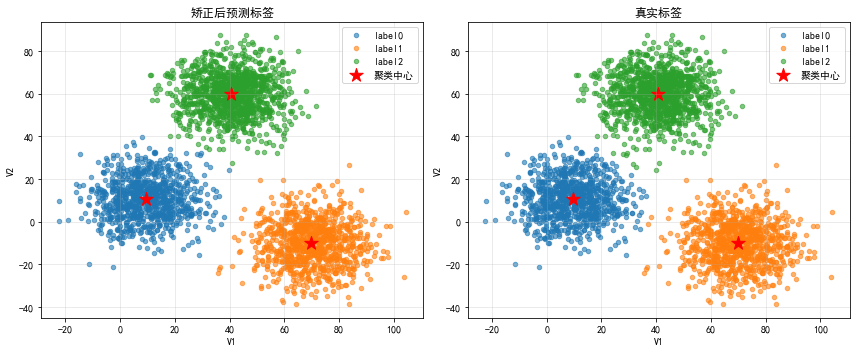

In [28]:
# ===================== 7. 对比可视化（矫正后 vs 真实标签） =====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 左图：矫正后预测标签
ax1.scatter(X['V1'][y_corrected==0], X['V2'][y_corrected==0], label='label0', alpha=0.6, s=20)
ax1.scatter(X['V1'][y_corrected==1], X['V2'][y_corrected==1], label='label1', alpha=0.6, s=20)
ax1.scatter(X['V1'][y_corrected==2], X['V2'][y_corrected==2], label='label2', alpha=0.6, s=20)
ax1.scatter(centers[:, 0], centers[:, 1], c='red', marker='*', s=200, label='聚类中心')
ax1.set_title("矫正后预测标签")
ax1.set_xlabel('V1')
ax1.set_ylabel('V2')
ax1.legend()
ax1.grid(alpha=0.3)

# 右图：真实标签
ax2.scatter(X['V1'][y==0], X['V2'][y==0], label='label0', alpha=0.6, s=20)
ax2.scatter(X['V1'][y==1], X['V2'][y==1], label='label1', alpha=0.6, s=20)
ax2.scatter(X['V1'][y==2], X['V2'][y==2], label='label2', alpha=0.6, s=20)
ax2.scatter(centers[:, 0], centers[:, 1], c='red', marker='*', s=200, label='聚类中心')
ax2.set_title("真实标签")
ax2.set_xlabel('V1')
ax2.set_ylabel('V2')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()